In [2]:
import numpy as np
import scipy as sp
from tqdm import tqdm
import matplotlib.pyplot as plt

In [3]:
N1 = 1000
N2 = 1
chi_c = (np.sqrt(N1) + np.sqrt(N2)) / (2 * np.sqrt(N1 * N2)) * (1 / np.sqrt(N1) + 1 / np.sqrt(N2))
Tc = 1 / chi_c
x_c = np.sqrt(N2) / (np.sqrt(N1) + np.sqrt(N2))

In [4]:
chi_sp = lambda x: 0.5 * (1 / (N1 * x) + 1 / (N2 * (1 - x)))
f = lambda x, chi: chi * x * (1 - x) + x / N1 * np.log(x) + (1 - x) / N2 * np.log(1 - x)
dfdx = lambda x, chi: chi * (1 - 2 * x) + (np.log(x) + 1) / N1 - (np.log(1 - x) + 1) / N2
p0 = lambda x, chi: f(x, chi) - dfdx(x, chi) * x

In [28]:
xs = np.linspace(0.0001, 0.9999, 9999)
Ts = np.linspace(0.01, 1 / chi_c, 99)
chi_sp_vals = chi_sp(xs)
ep_rel = 0.01
x_sp = []
T_sp = []
x_bi = []
T_bi = []

for ind_T, T in enumerate(tqdm(Ts[:-1])):
    chi = 1 / T

    # Finding the spinodal points
    mask_sp = np.abs(chi_sp_vals - chi) / chi < ep_rel
    sp_indices = np.where(mask_sp)[0]

    if len(sp_indices) < 2:
        continue

    idx_start, idx_end = sp_indices[0], sp_indices[-1]
    if xs[idx_start] >= x_c or xs[idx_end] <= x_c:
        continue
    x_sp.append([xs[idx_start], xs[idx_end]])
    T_sp.append(T)

    # Finding the binodal points
    xs_low = xs[:idx_start]
    xs_high = xs[idx_end:]


    dfdx_low = dfdx(xs_low, chi)
    p0_low = p0(xs_low, chi)
    dfdx_high = dfdx(xs_high, chi)
    p0_high = p0(xs_high, chi)

    diff_dfdx = np.abs(dfdx_low[:, None] - dfdx_high)
    diff_p0 = np.abs(p0_low[:, None] - p0_high)

    cond_mu = diff_dfdx / np.abs(dfdx_low[:, None]) < ep_rel * 20000
    cond_p0 = diff_p0 / np.abs(p0_low[:, None]) < ep_rel * 20000

    valid_pairs = cond_mu & cond_p0

    match_indices = np.argwhere(valid_pairs)
    if match_indices.size > 0:
        first_match = match_indices[0]
        x1_match = xs_low[first_match[0]]
        x2_match = xs_high[first_match[1]]

        x_bi.append([x1_match, x2_match])
        T_bi.append(T)

x_sp.append([x_c, x_c])
T_sp.append(Tc)
x_bi.append([x_c, x_c])
T_bi.append(Tc)

100%|██████████| 98/98 [00:00<00:00, 670.44it/s]


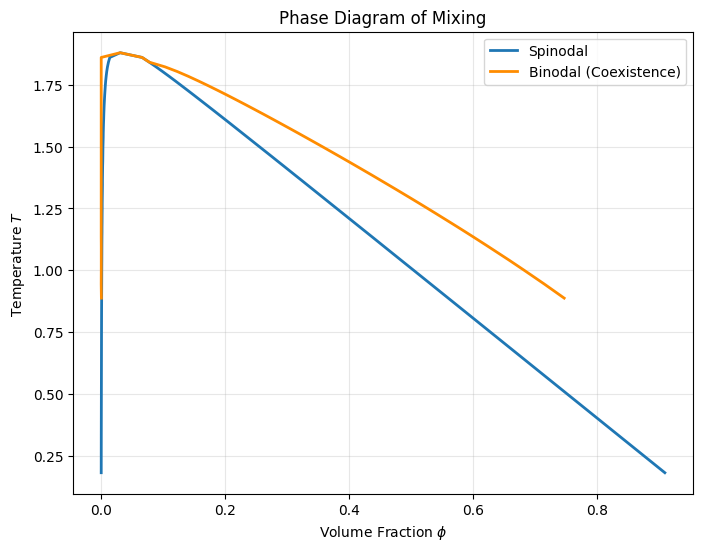

In [30]:
x_sp_arr = np.array(x_sp[:-1])
T_sp_arr = np.array(T_sp[:-1])

x_bi_arr = np.array(x_bi[:-1])
T_bi_arr = np.array(T_bi[:-1])

x_sp_smooth = np.concatenate([x_sp_arr[:, 0], [x_c], x_sp_arr[:, 1][::-1]])
T_sp_smooth = np.concatenate([T_sp_arr, [Tc], T_sp_arr[::-1]])

x_bi_smooth = np.concatenate([x_bi_arr[:, 0], [x_c], x_bi_arr[:, 1][::-1]])
T_bi_smooth = np.concatenate([T_bi_arr, [Tc], T_bi_arr[::-1]])

plt.figure(figsize=(8, 6))
plt.plot(x_sp_smooth, T_sp_smooth, label='Spinodal', color='tab:blue', linewidth=2)
plt.plot(x_bi_smooth, T_bi_smooth, label='Binodal (Coexistence)', color='darkorange', linewidth=2)

plt.xlabel('Volume Fraction $\phi$')
plt.ylabel('Temperature $T$')
plt.legend()
plt.title("Phase Diagram of Mixing")
plt.grid(True, alpha=0.3)
plt.show()